# 02. SQL 에이전트 (SQL Agent)

> **왜 SQL Agent가 필요한가요?**
>
> 데이터베이스에서 정보를 꺼내려면 SQL을 알아야 해요. 하지만 비개발자도 "지난달 매출 상위 10개 제품을 알려줘"라고 자연어로 물어보면 답을 얻을 수 있다면 훨씬 편리하겠죠? SQL Agent는 자연어 질문을 SQL 쿼리로 변환하고 실행까지 자동으로 해주는 에이전트예요.

> 🔑 **비유**: SQL Agent는 **데이터베이스 통역사**예요. 사용자의 한국어 질문을 SQL이라는 "데이터베이스 언어"로 번역해서 대신 질문하고, 결과를 다시 사람이 이해할 수 있는 말로 알려줘요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. SQL 에이전트의 7단계 쿼리 처리 흐름(테이블 탐색 → 스키마 조회 → 쿼리 생성 → 점검 → 실행)을 설명할 수 있어요
2. `SQLDatabaseToolkit`의 4가지 내장 도구(`QuerySQL`, `InfoSQL`, `ListSQL`, `CheckerSQL`)를 활용해 DB 조작 에이전트를 구성할 수 있어요
3. `create_tool_node_with_fallback`으로 에러를 포착하고 LLM에게 재시도 기회를 주는 오류 처리 패턴을 구현할 수 있어요
4. `SubmitFinalAnswer` Pydantic 스키마와 `should_continue` 라우터를 결합해 쿼리 자가 수정(self-correction) 루프를 설계할 수 있어요
5. `GradeAnswer` + `with_structured_output`을 활용한 LLM-as-Judge 평가 파이프라인을 구축할 수 있어요

## 사전 지식

- Part 2의 `04-StateGraph-Basics` - StateGraph, 노드, 엣지 개념
- Part 2의 `06-Tools-Integration` - ToolNode, tools_condition
- Part 11의 `01-Plan-And-Execute` - 다단계 에이전트 패턴
- SQL 기초 (SELECT, JOIN, GROUP BY)

---

## SQL 에이전트란?

**SQL 에이전트**는 사용자 질문을 해석해 **스키마를 탐색 → SQL을 생성 → 검증 → 실행 → 오류 시 자가 수정**하는 멀티스텝 에이전트예요. LangChain 공식 문서는 SQL 에이전트를 "데이터베이스를 자율적으로 탐색하고 답변을 도출하는 ReAct 기반 에이전트"로 설명해요.

### 핵심 구성 요소

| 구성 요소 | 역할 |
|-----------|------|
| `SQLDatabase` | LangChain의 DB 래퍼. 쿼리 실행, 스키마 조회, 방언(dialect) 정보 제공 |
| `SQLDatabaseToolkit` | 에이전트가 사용할 4개 표준 도구 묶음 (`list_tables`, `schema`, `query`, `query_checker`) |
| `SubmitFinalAnswer` | 최종 답변 형식을 강제하는 Pydantic 도구 스키마 |
| `create_tool_node_with_fallback` | 실행 오류를 ToolMessage로 변환해 LLM이 스스로 수정할 수 있게 하는 래퍼 |
| `should_continue` 라우터 | `Answer:` / `Error:` / 쿼리 3분기로 자가 수정 루프를 제어 |

> 🔑 **핵심 개념 — 자가 수정(self-correction) 루프**: LLM이 생성한 SQL이 실패하면 오류를 예외로 던지지 않고 **LLM이 읽을 수 있는 ToolMessage로 되돌려** 스스로 쿼리를 고치게 해요. 이 "피드백 루프"가 SQL 에이전트의 신뢰성을 만드는 핵심이에요.

> ⚠️ **안전 주의**: LLM이 생성한 SQL은 `DROP`, `DELETE`, `UPDATE` 같은 **파괴적 DML**을 포함할 수 있어요. 프로덕션에서는 반드시 **읽기 전용 DB 계정**을 사용하고, 변경이 필요한 쿼리는 Human-in-the-Loop로 승인을 받아야 해요.

## 1. 환경 설정

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# .env 파일에서 API 키 로드
load_dotenv(override=True)

True

In [2]:
import os

# LangSmith 추적 설정 (선택 사항)
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-SQL-Agent"

## 2. 데이터베이스 설정

이 튜토리얼에서는 **Chinook** 샘플 SQLite 데이터베이스를 사용해요.

Chinook은 디지털 미디어 스토어를 모델링한 데이터베이스로 다음 11개 테이블을 포함해요:

| 테이블 | 내용 |
|--------|------|
| `Artist`, `Album`, `Track` | 음악 카탈로그 |
| `Customer`, `Employee` | 고객 및 직원 정보 |
| `Invoice`, `InvoiceLine` | 구매 내역 |
| `Genre`, `MediaType`, `Playlist`, `PlaylistTrack` | 분류 및 재생목록 |

> 🔑 **핵심 개념**: SQLite는 파일 하나로 동작하는 내장형 데이터베이스예요. 별도 서버 설치 없이 Python 표준 라이브러리만으로 사용할 수 있어서 프로토타이핑에 최적이에요.

In [3]:
import requests

# Chinook 샘플 DB를 원격에서 다운로드해요
url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"

response = requests.get(url)

if response.status_code == 200:
    with open("Chinook.db", "wb") as file:
        file.write(response.content)
    # Chinook.db 다운로드 완료!
else:
    print(f"다운로드 실패. 상태 코드: {response.status_code}")

In [4]:
from langchain_community.utilities import SQLDatabase

# SQLite 데이터베이스 파일에서 SQLDatabase 인스턴스 생성
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

# DB 방언(dialect) 확인: sqlite
print("DB 방언:", db.dialect)

# 사용 가능한 테이블 목록 확인
print("테이블 목록:", db.get_usable_table_names())

# 샘플 쿼리 실행으로 정상 연결 확인
result = db.run("SELECT * FROM Artist LIMIT 5;")
print("\nArtist 테이블 샘플:", result)

DB 방언: sqlite
테이블 목록: ['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']

Artist 테이블 샘플: [(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]


## 3. LLM 및 SQLDatabaseToolkit 설정

> 💡 **실무 팁**: `SQLDatabaseToolkit`을 사용하면 DB 관련 도구 4개를 한번에 설정할 수 있어요. 각 도구를 직접 구현하는 것보다 훨씬 간편하죠.

In [5]:
from langchain.chat_models import init_chat_model
from langchain_community.agent_toolkits import SQLDatabaseToolkit

# ---------------------------------------------------
# LLM 초기화
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

# SQLDatabaseToolkit 생성: DB + LLM을 연결해요
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

# 사용 가능한 도구 목록 가져오기
tools = toolkit.get_tools()

# SQLDatabaseToolkit 도구 목록:
for t in tools:
    print(f"  - {t.name}")

  - sql_db_query
  - sql_db_schema
  - sql_db_list_tables
  - sql_db_query_checker


### SQLDatabaseToolkit 4가지 도구

| 도구 이름 | 역할 | 입력 |
|-----------|------|------|
| `sql_db_query` | SQL 실행 및 결과 반환 | 완전한 SQL 쿼리 문자열 |
| `sql_db_schema` | 테이블 DDL 및 샘플 데이터 조회 | 콤마 구분 테이블 이름 |
| `sql_db_list_tables` | DB 내 테이블 목록 조회 | 없음 |
| `sql_db_query_checker` | LLM 기반 쿼리 유효성 검사 | SQL 쿼리 문자열 |

In [6]:
# 도구 목록에서 필요한 도구를 이름으로 선택해요
list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

# 테이블 목록 도구 테스트
# === 테이블 목록 ===
print(list_tables_tool.invoke(""))

# 특정 테이블의 DDL 조회 테스트
# === Artist 테이블 DDL ===
print(get_schema_tool.invoke("Artist"))

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

CREATE TABLE "Artist" (
	"ArtistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("ArtistId")
)

/*
3 rows from Artist table:
ArtistId	Name
1	AC/DC
2	Accept
3	Aerosmith
*/


## 4. 오류 처리 패턴 구현

SQL 에이전트에서 가장 중요한 패턴 중 하나가 **오류 처리(Error Handling)**예요.

쿼리 실행 중 예외가 발생하면 에이전트를 그냥 종료하는 게 아니라, 오류 메시지를 LLM에게 전달해 스스로 수정하고 재시도할 수 있게 해요.

> 🔑 **핵심 개념**: `RunnableWithFallbacks`는 주 실행 체인이 실패할 때 대체 체인을 실행해요. `ToolNode.with_fallbacks([fallback_chain], exception_key="error")`로 오류를 포착하고 fallback 함수로 전달해요.

> ⚠️ **자주 하는 실수**: `ToolNode`를 fallback 없이 그냥 사용하면 예외 발생 시 그래프 전체가 멈춰요. SQL처럼 오류가 잦은 도구는 반드시 fallback을 설정해야 해요.

In [7]:
from typing import Any

from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph.prebuilt import ToolNode


def handle_tool_error(state) -> dict:
    """도구 오류를 포착해 LLM이 읽을 수 있는 ToolMessage로 변환해요."""
    # state에서 오류 정보 추출
    error = state.get("error")
    # 마지막 메시지에서 도구 호출 정보 추출
    tool_calls = state["messages"][-1].tool_calls
    # 각 도구 호출에 대응하는 오류 ToolMessage 생성
    return {
        "messages": [
            ToolMessage(
                content=f"오류가 발생했어요: {repr(error)}\n\n쿼리를 수정해주세요.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


def create_tool_node_with_fallback(tools: list) -> RunnableWithFallbacks[Any, dict]:
    """오류를 처리하고 에이전트에 오류 내용을 전달하는 ToolNode를 생성해요.

    오류 발생 시 handle_tool_error 함수를 fallback으로 실행하여
    에이전트가 오류를 인지하고 쿼리를 수정할 수 있도록 해요.
    """
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )


# 오류 처리 함수 정의 완료

## 5. SQL 쿼리 실행 도구 (`db_query_tool`)

`db_query_tool`은 에이전트가 실제로 SQL을 실행하는 핵심 도구예요.

`db.run_no_throw()` 메서드는 쿼리 실행 중 예외가 발생해도 raise하지 않고, 결과나 에러 정보를 문자열로 반환해요. 이를 통해 에이전트가 오류 메시지를 확인하고 스스로 쿼리를 수정할 수 있어요.

> 🔑 **핵심 개념**: `db.run_no_throw()`는 자가 수정(self-correction) 루프의 핵심이에요. 오류를 예외로 던지는 대신 문자열 메시지로 반환해서 LLM이 읽을 수 있게 해요.

In [8]:
from langchain.tools import tool


# @tool 데코레이터로 일반 함수를 에이전트 도구로 변환해요
@tool
def db_query_tool(query: str) -> str:
    """
    SQL 쿼리를 데이터베이스에 실행하고 결과를 반환해요.
    쿼리가 잘못되면 오류 메시지를 반환해요.
    오류 발생 시 쿼리를 수정하고 다시 시도하세요.
    """
    # 쿼리 실행 (오류가 발생해도 예외를 던지지 않아요)
    result = db.run_no_throw(query)

    # 결과가 없으면 오류 메시지 반환
    if not result:
        return "Error: 쿼리 실행에 실패했어요. 쿼리를 수정하고 다시 시도하세요."
    # 정상 실행 시 결과 반환
    return result

In [9]:
# 정상 쿼리 테스트
# === 정상 쿼리 실행 ===
print(db_query_tool.invoke("SELECT * FROM Artist LIMIT 5;"))

# === 오류 쿼리 테스트 (LIMITS는 없는 키워드) ===
print(db_query_tool.invoke("SELECT * FROM Artist LIMITS 5;"))

[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains')]
Error: (sqlite3.OperationalError) near "5": syntax error
[SQL: SELECT * FROM Artist LIMITS 5;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


## 6. SQL 쿼리 점검기 (Query Checker)

쿼리를 실행하기 전에 LLM이 쿼리를 검토하는 **쿼리 점검 단계**를 추가해요.

이 단계는 도구가 아닌 **그래프 노드**로 동작해요. `query_check` 체인이 쿼리를 검토하고, 항상 `db_query_tool`을 호출하는 형태로 결과를 반환하도록 `tool_choice="db_query_tool"`를 설정해요.

> 🔑 **핵심 개념**: `bind_tools([db_query_tool], tool_choice="db_query_tool")`는 LLM이 반드시 지정된 도구를 호출하도록 강제해요. 이를 통해 워크플로우의 예측 가능성을 높일 수 있어요.

LLM이 점검하는 일반적인 SQL 실수:
- `NOT IN`과 NULL 값 함께 사용
- `UNION` vs `UNION ALL` 선택
- `BETWEEN`의 경계값 포함 여부
- 데이터 타입 불일치
- 식별자 인용 방식
- JOIN 컬럼 정확성

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model

# ---------------------------------------------------
# SQL 쿼리 점검을 위한 시스템 메시지 정의
# ---------------------------------------------------
query_check_system = """You are a SQL expert with a strong attention to detail.
Double check the SQLite query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

You will call the appropriate tool to execute the query after running this check."""

# 프롬프트 템플릿 생성
query_check_prompt = ChatPromptTemplate.from_messages(
    [("system", query_check_system), ("placeholder", "{messages}")]
)

# 쿼리 점검 체인: tool_choice로 항상 db_query_tool을 호출하도록 강제해요
query_check = query_check_prompt | init_chat_model(
    "openai:gpt-4o-mini", temperature=0
).bind_tools([db_query_tool], tool_choice="db_query_tool")

# 쿼리 점검 체인 생성 완료

In [11]:
# 잘못된 쿼리를 넣어서 점검 결과 확인
# LIMITS → LIMIT으로 자동 수정되는지 확인해요
response = query_check.invoke(
    {"messages": [("user", "SELECT * FROM Artist LIMITS 10;")]}
)

# 점검 후 도구 호출 결과:
print(response.tool_calls[0])

{'name': 'db_query_tool', 'args': {'query': 'SELECT * FROM Artist LIMIT 10;'}, 'id': 'call_KLJVgUMJD3gOgLdNAWABdcTd', 'type': 'tool_call'}


## 7. StateGraph 정의

이제 모든 구성 요소를 `StateGraph`로 연결해요.

### 그래프 노드 구성

| 노드 이름 | 역할 |
|-----------|------|
| `first_tool_call` | 테이블 목록 조회 강제 실행 |
| `list_tables_tool` | 테이블 목록 반환 |
| `model_get_schema` | 관련 테이블 선택 |
| `get_schema_tool` | DDL 스키마 조회 |
| `query_gen` | SQL 쿼리 생성 또는 최종 답변 |
| `correct_query` | 쿼리 검증 및 수정 |
| `execute_query` | 검증된 쿼리 실행 |

> 💡 **실무 팁**: `first_tool_call` 노드를 별도로 두는 이유는 에이전트가 항상 테이블 목록 조회부터 시작하도록 강제하기 위해서예요. LLM이 자유롭게 시작하면 예측 불가능한 첫 번째 행동을 할 수 있거든요.

In [12]:
from typing import Annotated, Literal

from langchain_core.messages import AIMessage, ToolMessage
from langchain.chat_models import init_chat_model

from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.checkpoint.memory import MemorySaver


# ---------------------------------------------------
# 에이전트 상태 정의
# ---------------------------------------------------
# add_messages 리듀서: 메시지를 덮어쓰지 않고 누적해요
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


# State 타입 정의 완료

In [13]:
# ---------------------------------------------------
# 쿼리 생성 시스템 프롬프트
# ---------------------------------------------------
# 에이전트의 행동 규칙을 명확히 정의해요
QUERY_GEN_INSTRUCTION = """You are a SQL expert with a strong attention to detail.

Read the messages below and identify the user question, table schemas, query statement and query result, or error if they exist.

1. If there is no query result that makes sense to answer the question, create a syntactically correct SQLite query to answer the user question. DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

2. If you create a query, respond ONLY with the query statement. For example: "SELECT id, name FROM pets;"

3. If a query was already executed but there was an error, respond with the same error message. For example: "Error: Pets table doesn't exist"

4. If a query was already executed successfully, interpret the response and answer the question following this pattern: Answer: <<question answer>>. For example: "Answer: There are three cats registered as adopted"
"""

query_gen_prompt = ChatPromptTemplate.from_messages(
    [("system", QUERY_GEN_INSTRUCTION), ("placeholder", "{messages}")]
)

# ---------------------------------------------------
# 최종 답변 제출 스키마 (SubmitFinalAnswer)
# ---------------------------------------------------
# LLM이 최종 답변을 제출할 때 사용하는 구조화된 도구예요
class SubmitFinalAnswer(BaseModel):
    """쿼리 결과를 기반으로 사용자에게 최종 답변을 제출해요."""

    final_answer: str = Field(..., description="사용자에 대한 최종 답변")


# 쿼리 생성 체인: SubmitFinalAnswer 도구만 바인딩해요
# 중간 과정에서 다른 도구를 호출하지 않도록 강제해요
query_gen = query_gen_prompt | init_chat_model(
    "openai:gpt-4o-mini", temperature=0
).bind_tools([SubmitFinalAnswer])

# 쿼리 생성 체인 정의 완료

In [14]:
# ---------------------------------------------------
# 조건부 엣지: should_continue 라우터
# ---------------------------------------------------
# 세 가지 경로로 분기해요:
# 1. SubmitFinalAnswer 호출 또는 "Answer:" 응답 → END (완료)
# 2. "Error:" 응답 → query_gen (재시도)
# 3. 그 외 쿼리 텍스트 → correct_query (점검 후 실행)
def should_continue(state: State) -> Literal["__end__", "correct_query", "query_gen"]:
    messages = state["messages"]
    last_message = messages[-1]

    # SubmitFinalAnswer 도구 호출 시 워크플로우 종료
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tc in last_message.tool_calls:
            if tc["name"] == "SubmitFinalAnswer":
                return END

    # 텍스트 응답이 "Answer:"로 시작하면 종료
    if isinstance(last_message.content, str) and last_message.content.startswith(
        "Answer:"
    ):
        return END

    # 텍스트 응답이 "Error:"로 시작하면 쿼리 재생성
    if isinstance(last_message.content, str) and last_message.content.startswith(
        "Error:"
    ):
        return "query_gen"

    # 그 외 (쿼리 텍스트)는 쿼리 점검 노드로
    return "correct_query"


# 라우터 함수 정의 완료

In [15]:
# ---------------------------------------------------
# StateGraph 조립
# ---------------------------------------------------
workflow = StateGraph(State)


# 첫 번째 도구 호출 노드: 항상 테이블 목록 조회부터 시작해요
def first_tool_call(state: State) -> dict[str, list[AIMessage]]:
    """에이전트가 항상 테이블 목록 조회부터 시작하도록 강제해요."""
    return {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "sql_db_list_tables",  # 테이블 목록 조회 도구 지정
                        "args": {},
                        "id": "initial_tool_call_abc123",
                    }
                ],
            )
        ]
    }


# 쿼리 생성 노드: 잘못된 도구 호출 방지 로직 포함
def query_gen_node(state: State):
    """SQL 쿼리를 생성하거나 최종 답변을 제출해요."""
    message = query_gen.invoke(state)

    # LLM이 잘못된 도구를 호출하면 오류 메시지를 반환해요
    tool_messages = []
    if message.tool_calls:
        for tc in message.tool_calls:
            if tc["name"] != "SubmitFinalAnswer":
                tool_messages.append(
                    ToolMessage(
                        content=(
                            f"Error: 잘못된 도구가 호출됐어요: {tc['name']}. "
                            "SubmitFinalAnswer만 호출할 수 있어요. "
                            "쿼리는 도구 호출 없이 텍스트로만 출력하세요."
                        ),
                        tool_call_id=tc["id"],
                    )
                )
    return {"messages": [message] + tool_messages}


# 쿼리 점검 노드: query_check 체인으로 마지막 메시지의 쿼리를 검토해요
def model_check_query(state: State) -> dict[str, list[AIMessage]]:
    """LLM으로 쿼리의 정확성을 점검하고 db_query_tool 호출 형태로 반환해요."""
    return {"messages": [query_check.invoke({"messages": [state["messages"][-1]]})]}


# 관련 테이블 선택 모델: get_schema_tool을 바인딩해서 테이블 스키마를 조회해요
model_get_schema = init_chat_model("openai:gpt-4o-mini", temperature=0).bind_tools(
    [get_schema_tool]
)

# ---------------------------------------------------
# 노드 추가
# ---------------------------------------------------
workflow.add_node("first_tool_call", first_tool_call)  # 테이블 목록 강제 호출
workflow.add_node(
    "list_tables_tool", create_tool_node_with_fallback([list_tables_tool])
)  # 테이블 목록 반환
workflow.add_node(
    "get_schema_tool", create_tool_node_with_fallback([get_schema_tool])
)  # DDL 스키마 조회
workflow.add_node(
    "model_get_schema",
    lambda state: {"messages": [model_get_schema.invoke(state["messages"])]},
)  # 관련 테이블 선택
workflow.add_node("query_gen", query_gen_node)  # 쿼리 생성
workflow.add_node("correct_query", model_check_query)  # 쿼리 점검
workflow.add_node(
    "execute_query", create_tool_node_with_fallback([db_query_tool])
)  # 쿼리 실행

# ---------------------------------------------------
# 엣지 연결
# ---------------------------------------------------
workflow.add_edge(START, "first_tool_call")             # 시작 → 테이블 목록 조회
workflow.add_edge("first_tool_call", "list_tables_tool")  # → 테이블 목록 반환
workflow.add_edge("list_tables_tool", "model_get_schema")  # → 관련 테이블 선택
workflow.add_edge("model_get_schema", "get_schema_tool")   # → DDL 조회
workflow.add_edge("get_schema_tool", "query_gen")           # → 쿼리 생성
workflow.add_conditional_edges(
    "query_gen",
    should_continue,  # Answer/Error/쿼리 3방향 분기
)
workflow.add_edge("correct_query", "execute_query")  # 점검 → 실행
workflow.add_edge("execute_query", "query_gen")       # 실행 결과 → 쿼리 생성으로 피드백

# ---------------------------------------------------
# 그래프 컴파일: MemorySaver로 상태 영속성 제공
# ---------------------------------------------------
app = workflow.compile(checkpointer=MemorySaver())
# 그래프 컴파일 완료

## 8. 그래프 시각화

> 🎯 **강의 포인트**: 그래프를 시각화하면 조건부 엣지와 루프 구조를 한눈에 볼 수 있어요. `query_gen` → `correct_query` → `execute_query` → `query_gen`의 자가 수정 루프에 주목하세요!

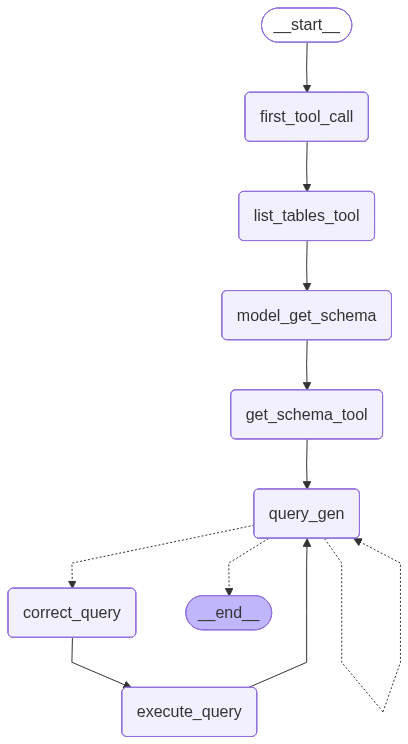

In [16]:
# 그래프 흐름: START → first_tool_call → list_tables_tool → model_get_schema → get_schema_tool → query_gen → (correct_query → execute_query → query_gen 루프) → END
# first_tool_call: 테이블 목록 조회를 강제로 시작해요
# model_get_schema / get_schema_tool: 관련 테이블의 DDL 스키마를 조회해요
# query_gen: SQL 쿼리를 생성하거나 최종 답변(SubmitFinalAnswer)을 반환해요
# correct_query → execute_query: 쿼리를 LLM으로 검증한 뒤 DB에서 실행해요 (오류 시 query_gen으로 재시도)
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## 9. SQL 에이전트 실행

에이전트를 실행해 자연어 질문을 SQL로 변환하고 결과를 확인해볼게요.

In [17]:
import uuid

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage
from langgraph.errors import GraphRecursionError


def run_sql_agent(message: str, recursion_limit: int = 30, verbose: bool = True):
    """SQL 에이전트를 실행하고 결과를 반환해요.

    Args:
        message: 자연어 질문
        recursion_limit: 최대 재귀 횟수 (기본값: 30)
        verbose: 노드별 출력 여부
    """
    # 각 실행마다 고유한 thread_id를 생성해요
    config = RunnableConfig(
        recursion_limit=recursion_limit,
        configurable={"thread_id": str(uuid.uuid4())},
    )

    # 입력 메시지 설정
    inputs = {"messages": [HumanMessage(content=message)]}

    try:
        # 스트리밍 모드로 실행해 노드별 결과를 출력해요
        for chunk in app.stream(inputs, config, stream_mode="updates"):
            for node_name, node_output in chunk.items():
                if verbose:
                    print(f"\n{'='*50}")
                    print(f"노드: {node_name}")
                    print(f"{'-'*50}")
                    if "messages" in node_output:
                        for msg in node_output["messages"]:
                            msg.pretty_print()

        # 최종 상태에서 결과 추출
        final_state = app.get_state(config).values
        return final_state

    except GraphRecursionError as e:
        print(f"재귀 한도 초과: {e}")
        return app.get_state(config).values


# 에이전트 실행 함수 준비 완료

In [18]:
# 예제 1: 직원 정보 조회
# 질문: Andrew Adams 직원의 인적정보를 모두 조회해줘
# ============================================================
output = run_sql_agent("Andrew Adams 직원의 인적정보를 모두 조회해줘")


노드: first_tool_call
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_abc123)
 Call ID: initial_tool_call_abc123
  Args:

노드: list_tables_tool
--------------------------------------------------
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

노드: model_get_schema
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_E8GGA26P8eJ0s0XpaR171NA8)
 Call ID: call_E8GGA26P8eJ0s0XpaR171NA8
  Args:
    table_names: Employee

노드: get_schema_tool
--------------------------------------------------
================================= Tool Message =================================
Name: sql_db_sche

In [19]:
# 예제 2: 집계 쿼리 (JOIN + GROUP BY)
# 질문: 2009년도에 어느 국가의 고객이 가장 많이 지출했나요?
# ============================================================
output = run_sql_agent(
    "2009년도에 어느 국가의 고객이 가장 많이 지출했나요? 그 금액도 알려주세요."
)


노드: first_tool_call
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_abc123)
 Call ID: initial_tool_call_abc123
  Args:

노드: list_tables_tool
--------------------------------------------------
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

노드: model_get_schema
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_dge8dHoKn5kAIkF2DcpGO2EU)
 Call ID: call_dge8dHoKn5kAIkF2DcpGO2EU
  Args:
    table_names: Customer, Invoice, InvoiceLine
  sql_db_schema (call_6vlExHIwKcPpZdhKgrTr3m7i)
 Call ID: call_6vlExHIwKcPpZdhKgrTr3m7i
  Args:
    table_names: Invoice

노드: get_schema_tool
------

## 10. 직접 실습해보세요

아래 TODO 블록을 수정해서 여러 가지 질문을 직접 실행해봐요!

In [20]:
# ============================================================
# TODO: 아래 질문을 원하는 것으로 바꿔서 실행해보세요
# 힌트:
#   - "가장 많이 팔린 장르는?" → Genre, Track, InvoiceLine 활용
#   - "Led Zeppelin의 앨범은 몇 개?" → Artist, Album 활용
#   - "2009년 가장 많이 판매한 영업 직원은?" → Employee, Invoice 활용
# 예상 결과: 에이전트가 테이블을 탐색하고 쿼리를 생성해 답변해요
# ============================================================

my_question = "가장 많은 트랙을 보유한 앨범은 무엇인가요?"

output = run_sql_agent(my_question, verbose=True)


노드: first_tool_call
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (initial_tool_call_abc123)
 Call ID: initial_tool_call_abc123
  Args:

노드: list_tables_tool
--------------------------------------------------
================================= Tool Message =================================
Name: sql_db_list_tables

Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

노드: model_get_schema
--------------------------------------------------
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_q3ERK6eYwL8zpI6vAkpVoJMq)
 Call ID: call_q3ERK6eYwL8zpI6vAkpVoJMq
  Args:
    table_names: Album, Track

노드: get_schema_tool
--------------------------------------------------
================================= Tool Message =================================
Name: sql_db_

## 11. LLM-as-Judge로 에이전트 평가하기

에이전트가 얼마나 정확한 답변을 생성하는지 **LLM-as-Judge** 방식으로 평가해요.

LLM-as-Judge는 또 다른 LLM이 에이전트의 응답을 평가하는 방법이에요. 고정된 규칙으로 평가하기 어려운 자연어 응답의 정확성을 자동으로 측정할 때 유용해요.

```mermaid
flowchart LR
    A["평가 데이터셋<br/>(질문 + 정답)"] --> B["SQL 에이전트<br/>(예측 함수)"]
    B --> C["예측 답변"]
    C --> D["LLM-as-Judge<br/>(GradeAnswer)"]
    A --> D
    D --> E["점수<br/>(0 or 1)"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    class A input
    class B,D process
    class C,E output
```

> 🔑 **핵심 개념**: `with_structured_output(GradeAnswer)`를 사용하면 LLM이 점수를 항상 `{"Score": 0}` 또는 `{"Score": 1}` 형태로 반환해요. 텍스트를 파싱하는 것보다 훨씬 안정적이에요.

In [21]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model


# ---------------------------------------------------
# 답변 평가 점수 스키마 정의
# ---------------------------------------------------
# Pydantic 모델로 LLM 출력 구조를 강제해요
class GradeAnswer(BaseModel):
    """답변의 정확도를 평가하는 점수 스키마예요."""

    Score: int = Field(description="0은 오답, 1은 정답")


# ---------------------------------------------------
# LLM-as-Judge 프롬프트 정의
# ---------------------------------------------------
grade_prompt_answer_accuracy = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER.

Here is the grade criteria to follow:
(1) Grade the student answers being not strictly wrong.
(2) Ensure the student answer does not contradict the correct answer.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is not contradictory.

Score: 1 means the student's answer meets all of the criteria.
Score: 0 means the student's answer does not meet all of the criteria.""",
        ),
        (
            "human",
            "QUESTION: {question}\n\nGROUND TRUTH ANSWER: {correct_answer}\n\nSTUDENT ANSWER: {student_answer}",
        ),
    ]
)


def answer_evaluator(run, example) -> dict:
    """LLM-as-Judge로 에이전트 응답의 정확도를 평가해요.

    Args:
        run: LangSmith 실행 결과 (예측 답변 포함)
        example: LangSmith 데이터셋 예제 (질문 + 정답 포함)

    Returns:
        평가 키와 점수 딕셔너리
    """
    # 평가에 필요한 세 가지 정보 추출
    input_question = example.inputs["input"]      # 원래 질문
    reference = example.outputs["output"]         # 정답
    prediction = run.outputs["response"]          # 에이전트 예측 답변

    # LLM 평가자 초기화: with_structured_output으로 점수를 안정적으로 추출
    llm = init_chat_model("openai:gpt-4o-mini", temperature=0)
    answer_grader = grade_prompt_answer_accuracy | llm.with_structured_output(
        GradeAnswer
    )

    # 평가 실행
    score = answer_grader.invoke(
        {
            "question": input_question,
            "correct_answer": reference,
            "student_answer": prediction,
        }
    )

    return {"key": "answer_v_reference_score", "score": score.Score}


# 평가 함수 정의 완료

In [22]:
from langsmith import Client

# LangSmith 클라이언트 초기화
client = Client()

# ---------------------------------------------------
# 평가용 데이터셋: (질문, 정답) 쌍
# ---------------------------------------------------
examples = [
    (
        "Which country's customers spent the most? And how much did they spend?",
        "The country whose customers spent the most is the USA, with a total spending of 523.06.",
    ),
    (
        "What was the most purchased track of 2013?",
        "The most purchased track of 2013 was Hot Girl.",
    ),
    (
        "How many albums does the artist Led Zeppelin have?",
        "Led Zeppelin has 14 albums",
    ),
    (
        "What is the total price for the album 'Big Ones'?",
        "The total price for the album 'Big Ones' is 14.85",
    ),
    (
        "Which sales agent made the most in sales in 2009?",
        "Steve Johnson made the most sales in 2009",
    ),
]

dataset_name = "SQL Agent Response"

# 데이터셋이 없을 때만 생성해요 (중복 방지)
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    inputs, outputs = zip(
        *[({"input": text}, {"output": label}) for text, label in examples]
    )
    client.create_examples(inputs=inputs, outputs=outputs, dataset_id=dataset.id)
    print(f"데이터셋 '{dataset_name}' 생성 완료 ({len(examples)}개 예제)")
else:
    print(f"데이터셋 '{dataset_name}'이 이미 존재해요. 기존 데이터셋을 재사용해요.")

LangSmithAuthError: Authentication failed for /datasets. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/datasets?limit=1&name=SQL+Agent+Response', '{"detail":"Invalid token"}')

In [ ]:
# ---------------------------------------------------
# 예측 함수: LangSmith evaluate()에서 호출돼요
# ---------------------------------------------------
def predict_sql_agent_answer(example: dict):
    """평가를 위한 SQL 에이전트 응답 예측 함수예요.

    Args:
        example: 입력 질문이 담긴 딕셔너리 {"input": "..."}

    Returns:
        에이전트 최종 답변이 담긴 딕셔너리 {"response": "..."}
    """
    config = RunnableConfig(
        configurable={"thread_id": str(uuid.uuid4())}
    )

    inputs = {"messages": [HumanMessage(content=example["input"])]}

    # 그래프를 실행하여 최종 메시지 추출
    messages = app.invoke(inputs, config)
    last_message = messages["messages"][-1]

    # SubmitFinalAnswer 도구 호출 시 final_answer 추출
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        for tc in last_message.tool_calls:
            if tc["name"] == "SubmitFinalAnswer":
                return {"response": tc["args"].get("final_answer", "")}

    # 텍스트 응답인 경우 그대로 반환
    return {"response": last_message.content}


# 예측 함수 정의 완료

In [ ]:
from langsmith.evaluation import evaluate

# ---------------------------------------------------
# LangSmith evaluate() 실행
# ---------------------------------------------------
# num_repetitions=3: 동일 테스트를 3회 반복해 평균 성능을 측정해요
# LLM의 확률적 특성 때문에 단일 실행보다 반복 실행이 더 신뢰도 높은 결과를 줘요
experiment_results = evaluate(
    predict_sql_agent_answer,          # 예측 함수
    data=dataset_name,                 # 평가 데이터셋
    evaluators=[answer_evaluator],     # 평가자 목록
    num_repetitions=1,                 # 실험 반복 횟수 (시간 절약을 위해 1회)
    experiment_prefix="sql-agent-gpt4o-mini",
    metadata={
        "version": "chinook db, model: gpt-4o-mini"
    },
)
# 평가 완료! LangSmith 대시보드에서 결과를 확인하세요.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **SQL 에이전트 7단계 흐름**: 테이블 목록 → 테이블 선택 → DDL 조회 → 쿼리 생성 → 점검 → 실행 → 답변 생성 순서로 처리해요
- **SQLDatabaseToolkit**: `sql_db_list_tables`, `sql_db_schema`, `sql_db_query`, `sql_db_query_checker` 4가지 도구를 제공해 DB 탐색을 쉽게 해요
- **create_tool_node_with_fallback**: `ToolNode.with_fallbacks()`로 오류를 포착하고 LLM이 읽을 수 있는 ToolMessage로 변환해요
- **db_query_tool + run_no_throw**: 예외를 던지는 대신 오류 문자열을 반환해서 자가 수정(self-correction) 루프를 구현해요
- **should_continue 라우터**: `Answer:` / `Error:` / 쿼리 텍스트의 3방향 분기로 쿼리 재시도 루프를 제어해요
- **SubmitFinalAnswer + bind_tools**: Pydantic 스키마와 `tool_choice`로 LLM이 항상 구조화된 최종 답변을 제출하도록 강제해요
- **GradeAnswer + with_structured_output**: LLM-as-Judge 평가에서 점수를 안정적으로 추출하는 패턴이에요

---

## 다음 노트북 예고

다음 `03-Deep-Research-Agent.ipynb`에서는 **다단계 웹 리서치 에이전트**를 배워요. **STORM 패턴**으로 다양한 관점의 분석가 페르소나를 생성하고, `Send()` map-reduce로 여러 인터뷰를 **병렬 실행**한 뒤 결과를 종합해 보고서를 작성해요. 여기에 `interrupt_before`로 사용자가 분석가 구성에 개입할 수 있는 HITL까지 추가해요.

<!-- AUTOPILOT_CREATE_AGENT_DEEP_AGENT_APPENDIX -->
## 보강: `create_agent`로 SQL Agent를 더 간결하게 구현하기

### 참고 공식 문서
- [Build a SQL agent](https://docs.langchain.com/oss/python/langchain/sql-agent)
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)

이 노트북의 본문은 SQL 에이전트의 내부 구조를 이해하기 위해 `StateGraph`로 7단계 파이프라인을 직접 만들었어요. 이 방식은 **쿼리 생성, 검증, 실행, 재시도**를 노드 단위로 관찰하기 좋습니다.

하지만 공식 LangChain SQL Agent 문서에서는 실무용 기본선으로 `create_agent(model, tools, system_prompt=...)` 패턴을 제안해요. `SQLDatabaseToolkit`이 제공하는 도구들을 그대로 넘기면, 에이전트가 다음 루프를 자동으로 수행합니다.

1. 테이블 목록 확인
2. 관련 스키마 조회
3. 자연어 질문을 SQL로 변환
4. SQL 실행
5. 오류가 있으면 오류 메시지를 읽고 쿼리 수정
6. 최종 답변 생성

이 접근은 다음 상황에서 특히 좋아요.

- 빠르게 SQL Agent MVP를 만들고 싶을 때
- 수동 `StateGraph` 구현과 비교할 baseline이 필요할 때
- LangSmith로 전체 tool-calling trajectory를 평가하고 싶을 때
- 노드별 완전 제어보다 구현 단순성이 더 중요할 때

반대로 **쿼리 검증 정책을 매우 엄격하게 분리**하거나, 각 단계의 실패 처리를 교육용으로 보여줘야 한다면 본문의 `StateGraph` 구현이 더 적합해요.

> 안전 팁: SQL 에이전트는 반드시 읽기 전용 DB 계정, `top_k` 제한, DML 금지 프롬프트, LangSmith 추적을 함께 사용하세요.


In [ ]:
# ============================================================
# 선택 실행: create_agent 기반 SQL Agent baseline
# ============================================================
# 본문에서 만든 StateGraph 버전과 비교하기 위한 간결한 구현이에요.
# 외부 API 키와 DB 객체가 준비되었을 때만 True로 바꾸세요.
RUN_CREATE_AGENT_SQL_APPENDIX = False

if RUN_CREATE_AGENT_SQL_APPENDIX:
    from langchain.agents import create_agent
    from langchain.chat_models import init_chat_model
    from langchain_community.agent_toolkits import SQLDatabaseToolkit

    # --------------------------------------------------------
    # 1) 본문에서 사용한 db 객체를 그대로 재사용해요.
    # --------------------------------------------------------
    # db = SQLDatabase.from_uri("sqlite:///Chinook.db")  # 필요하면 직접 생성
    model = init_chat_model("openai:gpt-4o-mini", temperature=0)
    toolkit = SQLDatabaseToolkit(db=db, llm=model)
    tools = toolkit.get_tools()

    # --------------------------------------------------------
    # 2) 공식 문서 스타일의 SQL 안전 프롬프트
    # --------------------------------------------------------
    # 핵심은 "항상 테이블 목록 → 스키마 확인 → 쿼리 작성" 순서를 지시하고,
    # INSERT/UPDATE/DELETE/DROP 같은 DML을 명시적으로 금지하는 거예요.
    system_prompt = f"""
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {db.dialect} query,
execute it, inspect the result, and answer in Korean.

Rules:
- Always inspect the available tables first. Do not skip this step.
- Then inspect the schema of the most relevant tables.
- Limit result rows to at most 5 unless the user explicitly asks otherwise.
- Never query all columns when only a few columns are relevant.
- Double-check the query before executing it.
- If execution returns an error, revise the SQL and try again.
- Never make DML statements such as INSERT, UPDATE, DELETE, DROP, ALTER, or CREATE.
"""

    # --------------------------------------------------------
    # 3) create_agent는 내부적으로 LangGraph 기반 런타임을 구성해요.
    # --------------------------------------------------------
    sql_agent = create_agent(
        model=model,
        tools=tools,
        system_prompt=system_prompt,
    )

    # --------------------------------------------------------
    # 4) 실행 예시
    # --------------------------------------------------------
    result = sql_agent.invoke({
        "messages": [{"role": "user", "content": "매출이 가장 높은 장르 5개를 알려줘"}]
    })

    print(result["messages"][-1].content)
